In [77]:
from sklearn.datasets import make_circles

# Make 1000 samples 
n_samples = 1000
# Create circles
X, y = make_circles(n_samples, noise=0.03,random_state=42) 

In [78]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [79]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [80]:
circles.label.value_counts()

,count
label,
1,500
0,500


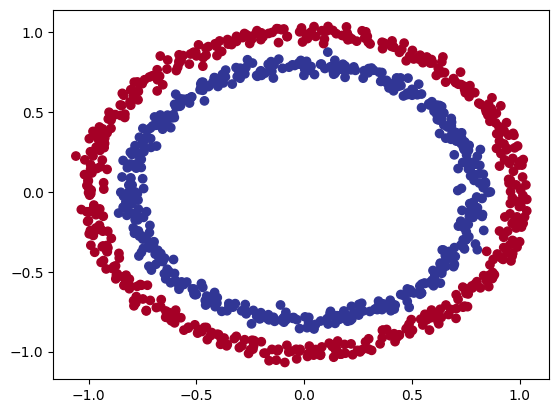

In [81]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

In [82]:
X.shape, y.shape

((1000, 2), (1000,))

In [83]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [84]:
import torch
from torch import nn

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

len(X_train), len(X_test) ,len(y_train), len(y_train)

(800, 200, 800, 800)

In [86]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [87]:
# Create the model
class circleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=10)
        self.layer_4 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

model_0 = circleModel().to(device)
model_0

circleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [88]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.2096],
        [0.2006],
        [0.2128],
        [0.2075],
        [0.2118],
        [0.2151],
        [0.1848],
        [0.1905],
        [0.2126],
        [0.1997]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [89]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

# Calculate accuracy (a evaluation metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [90]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model_0(X_test.to(device))[:5]
y_logits

# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [91]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [92]:
# Training loop
torch.manual_seed(42)

epochs = 20000
# Place data into target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training loop
for epoch in range(epochs):
    model_0.train()

    # 1 Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) 

    # 2 Calculate loss / accuracy

    loss = loss_fn(y_logits, y_train)
    accuracy = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3 Optimizer zero grad
    optimizer.zero_grad()
    # 4 Loss backward
    loss.backward()
    # 5 Optimizer step
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {accuracy:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69815, Accuracy: 50.00% | Test loss: 0.69751, Test acc: 50.00%
Epoch: 10 | Loss: 0.69562, Accuracy: 50.00% | Test loss: 0.69510, Test acc: 50.00%
Epoch: 20 | Loss: 0.69421, Accuracy: 50.00% | Test loss: 0.69377, Test acc: 50.00%
Epoch: 30 | Loss: 0.69343, Accuracy: 50.00% | Test loss: 0.69302, Test acc: 50.00%
Epoch: 40 | Loss: 0.69299, Accuracy: 50.00% | Test loss: 0.69260, Test acc: 50.00%
Epoch: 50 | Loss: 0.69275, Accuracy: 50.00% | Test loss: 0.69236, Test acc: 50.00%
Epoch: 60 | Loss: 0.69260, Accuracy: 50.50% | Test loss: 0.69221, Test acc: 51.00%
Epoch: 70 | Loss: 0.69250, Accuracy: 57.25% | Test loss: 0.69211, Test acc: 59.50%
Epoch: 80 | Loss: 0.69244, Accuracy: 57.25% | Test loss: 0.69204, Test acc: 59.00%
Epoch: 90 | Loss: 0.69239, Accuracy: 54.62% | Test loss: 0.69199, Test acc: 53.50%
Epoch: 100 | Loss: 0.69235, Accuracy: 52.75% | Test loss: 0.69194, Test acc: 52.50%
Epoch: 110 | Loss: 0.69231, Accuracy: 52.50% | Test loss: 0.69190, Test acc: 52.00%
Epo

helper_functions.py already exists, skipping download


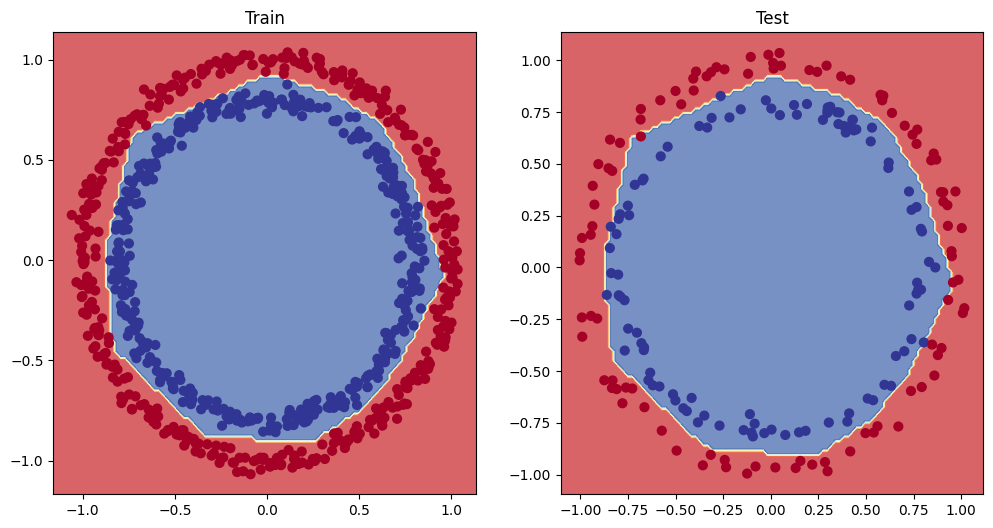

In [93]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [94]:
### Multi Classifcation Problem ###

In [95]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [96]:
# Set hyper paramaters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

In [97]:
# Create multi class dataset
X_blob, y_blob = make_blobs(n_samples=10000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels 
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

In [98]:
# convert data into pytorch format to enable learning and predicting
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

tensor([[ -3.1987,   7.3945],
        [ -9.0976, -10.2246],
        [  5.5605,   2.5364],
        [ -8.1341,  -9.6798],
        [ -5.8277,  -5.7955]]) tensor([0, 2, 1, 2, 2])


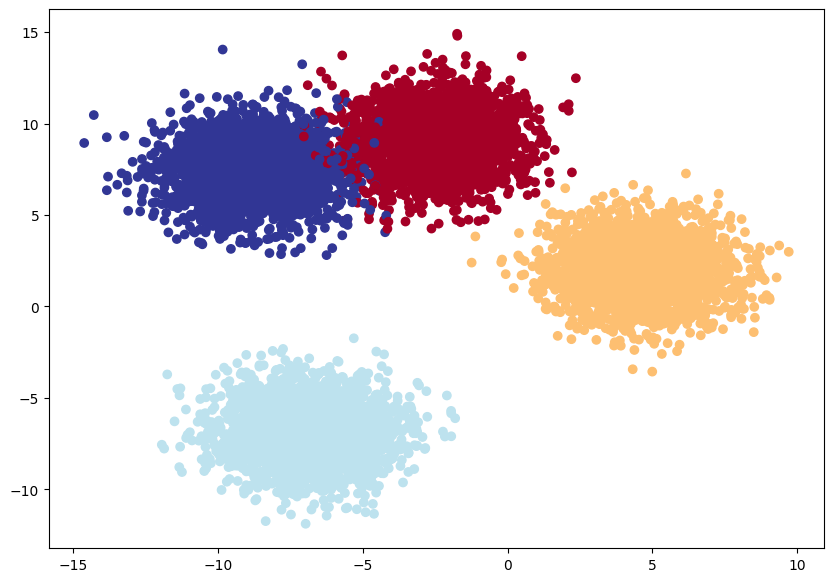

In [99]:
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);